<a href="https://colab.research.google.com/github/yo-danny/speech-emotion-recognition/blob/main/speech_emotion_recognition_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Speech Emotion Recognition



### Imports

In [1]:
import librosa
import soundfile
import os, glob, pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from librosa.feature import spectral_centroid, spectral_rolloff, zero_crossing_rate

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

from keras import Sequential
from keras.layers import Dense, LSTM, Dropout, Activation
from keras.layers import MaxPooling1D, Conv1D
from keras.callbacks import ModelCheckpoint
from keras.callbacks import EarlyStopping

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

Defining a function to extract features from the audio.

In [2]:
def extract_feature(file_name, mfcc, chroma, mel, spectral_centroid, spectral_rolloff, zero_crossing_rate):
    with soundfile.SoundFile(file_name) as sound_file:
        X = sound_file.read(dtype="float32")
        sample_rate=sound_file.samplerate
        if chroma:
            stft=np.abs(librosa.stft(X))
        result=np.array([])
        if mfcc: # mapping sound to human perception to identify phonetic content
            mfccs=np.mean(librosa.feature.mfcc(y=X, sr=sample_rate, n_mfcc=40).T, axis=0)
            result=np.hstack((result, mfccs))
        if chroma: # analyzing the harmonic and tonal content
            chroma=np.mean(librosa.feature.chroma_stft(S=stft, sr=sample_rate).T,axis=0)
            result=np.hstack((result, chroma))
        if mel: # visual representations of audio frequency over time
            mel=np.mean(librosa.feature.melspectrogram(y=X, sr=sample_rate).T,axis=0)
            result=np.hstack((result, mel))
        if spectral_centroid: # tells you where the middle of the frequency spectrum is (the "average" frequency)
            spectral_centroid = np.mean(librosa.feature.spectral_centroid(y=X, sr=sample_rate).T,axis=0)
            result=np.hstack((result, spectral_centroid))
        if spectral_rolloff: # tells you where the edge of the majority of energy lies (usually 95% or 85% of the energy is below this point)
            spectral_rolloff = np.mean(librosa.feature.spectral_rolloff(y=X, sr=sample_rate).T,axis=0)
            result=np.hstack((result, spectral_rolloff))
        if zero_crossing_rate: # counts how often the signal crosses the zero axis, used to distinguish noisy, high-energy emotions
            zero_crossing_rate = np.mean(librosa.feature.zero_crossing_rate(y=X).T,axis=0)
            result=np.hstack((result, zero_crossing_rate))
    return result

Dictionary to hold number values for emotions avaible in the RAVDESS dataset.

In [3]:
emotions = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

observed_emotions=['calm', 'happy', 'fearful', 'disgust']

### Loading the data

Function to load the data from our ambient, calls the extraction of features and return the train and test datasets for model training.

In [4]:
def load_data(test_size=0.2):
    x, y = [], []
    for file in glob.glob("/content/drive/MyDrive/speech-emotion-recognition-ravdess-data/Actor_*/*.wav"):
        file_name = os.path.basename(file)
        emotion=emotions[file_name.split("-")[2]]
        if emotion not in observed_emotions:
            continue
        feature = extract_feature(file_name=file, mfcc=True, chroma=True, mel=True, spectral_centroid=True, spectral_rolloff=True, zero_crossing_rate=True)
        x.append(feature)
        y.append(emotion)
    return np.array(np.expand_dims(x, axis=2)), np.array(y)


In [5]:
all_features, all_labels = load_data()

x_train, x_test, y_train, y_test = train_test_split(all_features, all_labels, test_size=0.25, random_state=42, stratify=all_labels)

lb = LabelBinarizer()
y_train_encoded = lb.fit_transform(y_train)
y_test_encoded = lb.transform(y_test)

### First Trained Model: CNN

Initializing the CNN model.

In [7]:
model = Sequential()
model.add(Conv1D(64, 5, padding='same', input_shape=(x_train.shape[1], 1)))
model.add(Activation('relu'))
model.add(MaxPooling1D(pool_size=8))
model.add(Dropout(0.2))
model.add(Conv1D(128, 5, padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling1D(pool_size=8))
model.add(Dropout(0.2))
model.add(LSTM(128))
model.add(Dropout(0.2))
model.add(Dense(len(observed_emotions)))
model.add(Activation('softmax'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 183, 64)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 183, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 22, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 22, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 22, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 22, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           516 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173,572 (678.02 KB)

 Trainable params: 173,572 (678.02 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(x_train, y_train_encoded, batch_size = 16, epochs=100, validation_data=(x_test, y_test_encoded), callbacks=[early_stopping])

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.2899 - loss: 1.3586 - val_accuracy: 0.3594 - val_loss: 1.3016
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.3594 - loss: 1.2794 - val_accuracy: 0.3750 - val_loss: 1.2637
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3924 - loss: 1.2335 - val_accuracy: 0.4375 - val_loss: 1.2259
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.4358 - loss: 1.1822 - val_accuracy: 0.4115 - val_loss: 1.2046
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.4618 - loss: 1.1731 - val_accuracy: 0.4271 - val_loss: 1.1921
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.4549 - loss: 1.1579 - val_accuracy: 0.4219 - val_loss: 1.2160
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.4844 - loss: 1.1394 - val_accuracy: 0.4792 - val_loss: 1.1645
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.4670 - loss: 1.1393 - val_accuracy: 0.

Predicting and evaluating the model.

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 183, 64)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 183, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 22, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 22, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 22, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 22, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           516 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 520,718 (1.99 MB)

 Trainable params: 173,572 (678.02 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 347,146 (1.32 MB)

None
Accuracy: 52.60%
Precision: 52.60%
Recall: 52.60%
F1-Score: 51.66%


<Axes: >

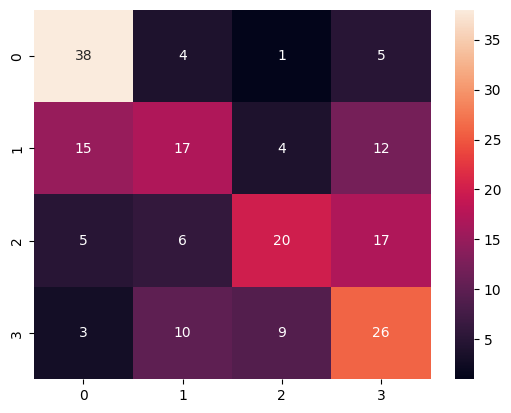

In [9]:
y_pred = model.predict(x_test)

y_pred_encoded = lb.inverse_transform(y_pred)

accuracy=accuracy_score(y_true=y_test, y_pred=y_pred_encoded)
precision=precision_score(y_true=y_test, y_pred=y_pred_encoded, average='macro')
recall=recall_score(y_true=y_test, y_pred=y_pred_encoded, average='macro')
f1=f1_score(y_true=y_test, y_pred=y_pred_encoded, average='macro')

print(model.summary())

print("Accuracy: {:.2f}%".format(accuracy*100))
print("Precision: {:.2f}%".format(precision*100))
print("Recall: {:.2f}%".format(recall*100))
print("F1-Score: {:.2f}%".format(f1*100))

sns.heatmap(confusion_matrix(y_test, y_pred_encoded), annot=True)

### Alternative Model: XGBoost Classifier

In [6]:
x_train_mlp = x_train.reshape(x_train.shape[0], x_train.shape[1])
x_test_mlp = x_test.reshape(x_test.shape[0], x_test.shape[1])

In [10]:
# Initialize the XGBoost Classifier
xgb_model = XGBClassifier(objective='multi:softmax', num_class=len(observed_emotions), eval_metric='mlogloss', use_label_encoder=False, random_state=42)

# Encode string labels to integers
le = LabelEncoder()
# Fit on the training labels and transform both training and testing labels
y_train_numeric = le.fit_transform(y_train)
y_test_numeric = le.transform(y_test) # Transform y_test using the *same* encoder fitted on y_train

# Train the XGBoost model
# Note: XGBoost expects integer labels for multi-class classification (0, 1, ..., num_class-1).
# We have converted y_train from string labels to these integer labels.
xgb_model.fit(x_train_mlp, y_train_numeric) # Use numeric labels

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:52:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, num_class=4, ...)

XGBoost Model Evaluation:
Accuracy: 68.23%
Precision: 68.11%
Recall: 68.23%
F1-Score: 67.42%


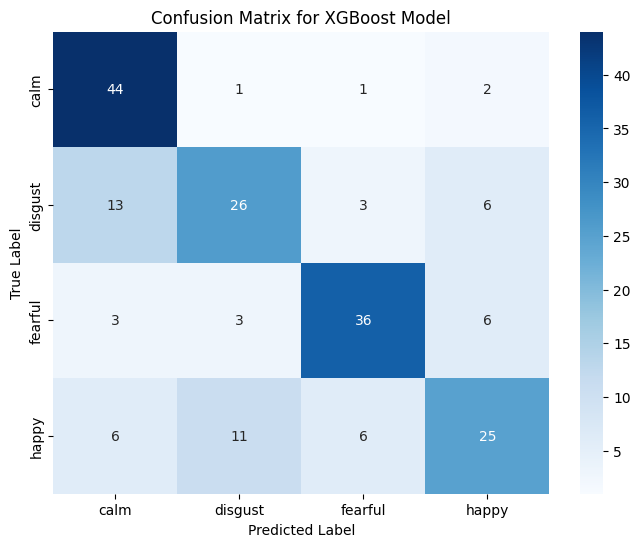

In [11]:
# Evaluate the XGBoost model
xgb_y_pred = xgb_model.predict(x_test_mlp)

xgb_accuracy = accuracy_score(y_true=y_test_numeric, y_pred=xgb_y_pred)
xgb_precision = precision_score(y_true=y_test_numeric, y_pred=xgb_y_pred, average='macro')
xgb_recall = recall_score(y_true=y_test_numeric, y_pred=xgb_y_pred, average='macro')
xgb_f1 = f1_score(y_true=y_test_numeric, y_pred=xgb_y_pred, average='macro')

print("XGBoost Model Evaluation:")
print("Accuracy: {:.2f}%".format(xgb_accuracy*100))
print("Precision: {:.2f}%".format(xgb_precision*100))
print("Recall: {:.2f}%".format(xgb_recall*100))
print("F1-Score: {:.2f}%".format(xgb_f1*100))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_numeric, xgb_y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=lb.classes_, yticklabels=lb.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for XGBoost Model')
plt.show()

### Third Trained Model: MLPClassifier

In [12]:
# Initialize the MLPClassifier model
mlp_model = MLPClassifier(alpha=0.01, batch_size=256, epsilon=1e-08, hidden_layer_sizes=(300,), learning_rate='adaptive', max_iter=500)

# Train the MLPClassifier model
mlp_model.fit(x_train_mlp, y_train_encoded)

# Make predictions with the MLPClassifier
y_pred_mlp = mlp_model.predict(x_test_mlp)

In [13]:
y_pred_mlp_decoded = lb.inverse_transform(y_pred_mlp)

accuracy_mlp = accuracy_score(y_true=y_test, y_pred=y_pred_mlp_decoded)
precision_mlp = precision_score(y_true=y_test, y_pred=y_pred_mlp_decoded, average='macro')
recall_mlp = recall_score(y_true=y_test, y_pred=y_pred_mlp_decoded, average='macro')
f1_mlp = f1_score(y_true=y_test, y_pred=y_pred_mlp_decoded, average='macro')

print("MLPClassifier Model Evaluation:")
print("Accuracy: {:.2f}%".format(accuracy_mlp*100))
print("Precision: {:.2f}%".format(precision_mlp*100))
print("Recall: {:.2f}%".format(recall_mlp*100))
print("F1-Score: {:.2f}%".format(f1_mlp*100))

MLPClassifier Model Evaluation:
Accuracy: 40.10%
Precision: 68.62%
Recall: 40.10%
F1-Score: 33.42%


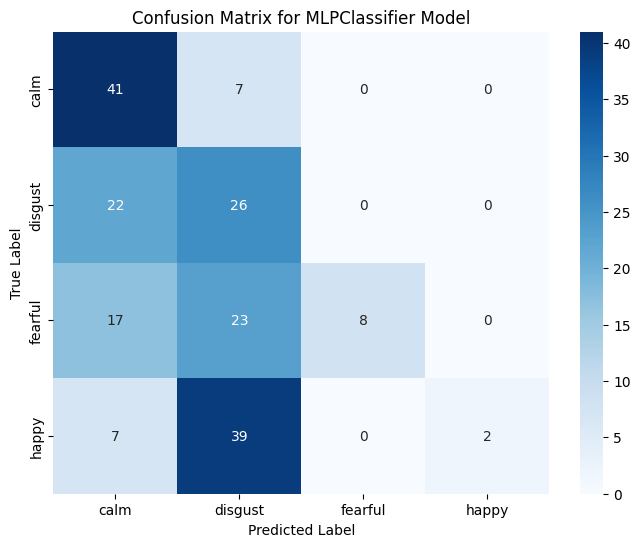

In [14]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_mlp_decoded), annot=True, fmt='d', cmap='Blues',
            xticklabels=lb.classes_, yticklabels=lb.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for MLPClassifier Model')
plt.show()

### Ensemble Model: Stacking CNN and XGBoost

In [20]:
from sklearn.model_selection import StratifiedKFold
from keras.models import clone_model
from keras.layers import Input

# Define the number of folds for cross-validation
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Initialize arrays to store out-of-fold predictions for the meta-classifier training
# These will be the meta-features for the meta-classifier trained on the training set
meta_features_train = np.zeros((x_train.shape[0], model.output_shape[1] + len(observed_emotions)))

# Initialize arrays to store test set predictions from each fold's base models
# We'll average these to get the meta-features for the test set
cnn_test_preds_folds = np.zeros((x_test.shape[0], model.output_shape[1], n_splits))
xgb_test_preds_folds = np.zeros((x_test.shape[0], len(observed_emotions), n_splits))

# Loop through each fold
print(f"Generating out-of-fold predictions across {n_splits} folds...")
for fold, (train_idx, val_idx) in enumerate(skf.split(x_train, y_train_numeric)):
    print(f"--- Fold {fold+1}/{n_splits} ---")

    # Prepare data for the current fold
    x_train_fold_cnn, x_val_fold_cnn = x_train[train_idx], x_train[val_idx]
    y_train_fold_cnn_encoded, y_val_fold_cnn_encoded = y_train_encoded[train_idx], y_train_encoded[val_idx]

    x_train_fold_xgb, x_val_fold_xgb = x_train_mlp[train_idx], x_train_mlp[val_idx]
    y_train_fold_xgb_numeric, y_val_fold_xgb_numeric = y_train_numeric[train_idx], y_train_numeric[val_idx]

    # 1. Train CNN model for the current fold
    # Re-create and compile the model to ensure fresh weights each fold
    cnn_model_fold = Sequential()
    cnn_model_fold.add(Conv1D(64, 5, padding='same', input_shape=(x_train.shape[1], 1)))
    cnn_model_fold.add(Activation('relu'))
    cnn_model_fold.add(MaxPooling1D(pool_size=8))
    cnn_model_fold.add(Dropout(0.2))
    cnn_model_fold.add(Conv1D(128, 5, padding='same'))
    cnn_model_fold.add(Activation('relu'))
    cnn_model_fold.add(MaxPooling1D(pool_size=8))
    cnn_model_fold.add(Dropout(0.2))
    cnn_model_fold.add(LSTM(128))
    cnn_model_fold.add(Dropout(0.2))
    cnn_model_fold.add(Dense(len(observed_emotions)))
    cnn_model_fold.add(Activation('softmax'))

    cnn_model_fold.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    cnn_model_fold.fit(x_train_fold_cnn, y_train_fold_cnn_encoded, batch_size=16, epochs=50, verbose=0) # epochs reduced for faster example

    # Get out-of-fold predictions for CNN
    oof_cnn_preds = cnn_model_fold.predict(x_val_fold_cnn)
    meta_features_train[val_idx, :model.output_shape[1]] = oof_cnn_preds

    # Get test set predictions for CNN (for averaging later)
    cnn_test_preds_folds[:, :, fold] = cnn_model_fold.predict(x_test)

    # 2. Train XGBoost model for the current fold
    # Re-create the model to ensure fresh weights each fold
    xgb_model_fold = XGBClassifier(objective='multi:softmax', num_class=len(observed_emotions), eval_metric='mlogloss', use_label_encoder=False, random_state=42)
    xgb_model_fold.fit(x_train_fold_xgb, y_train_fold_xgb_numeric)

    # Get out-of-fold predictions for XGBoost
    oof_xgb_preds = xgb_model_fold.predict_proba(x_val_fold_xgb)
    meta_features_train[val_idx, model.output_shape[1]:] = oof_xgb_preds

    # Get test set predictions for XGBoost (for averaging later)
    xgb_test_preds_folds[:, :, fold] = xgb_model_fold.predict_proba(x_test_mlp)

print("Out-of-fold prediction generation complete.")

Generating out-of-fold predictions across 5 folds...
--- Fold 1/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:00:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- Fold 2/5 ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


...

--- Fold 4/5 ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:02:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- Fold 5/5 ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:03:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Out-of-fold prediction generation complete.


Now that we have the out-of-fold predictions from our base models (CNN and XGBoost) on the training data, we can create the meta-features for our meta-classifier. For the test set, we average the predictions from each fold to get robust meta-features.

In [21]:
# Average the test predictions across all folds
meta_features_test = np.hstack((
    np.mean(cnn_test_preds_folds, axis=2),
    np.mean(xgb_test_preds_folds, axis=2)
))

print(f"Shape of meta-features for training meta-classifier: {meta_features_train.shape}")
print(f"Shape of meta-features for test set: {meta_features_test.shape}")

Shape of meta-features for training meta-classifier: (576, 8)
Shape of meta-features for test set: (192, 8)


In [22]:
# Train the meta-classifier on the out-of-fold predictions
ensemble_meta_classifier = LogisticRegression(solver='lbfgs', multi_class='multinomial', random_state=42, max_iter=1000)
ensemble_meta_classifier.fit(meta_features_train, y_train_numeric)

print("Meta-classifier training complete.")

Meta-classifier training complete.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [23]:
# Make final predictions with the ensemble model on the test set
final_ensemble_y_pred = ensemble_meta_classifier.predict(meta_features_test)

# Evaluate the ensemble model
final_ensemble_accuracy = accuracy_score(y_true=y_test_numeric, y_pred=final_ensemble_y_pred)
final_ensemble_precision = precision_score(y_true=y_test_numeric, y_pred=final_ensemble_y_pred, average='macro')
final_ensemble_recall = recall_score(y_true=y_test_numeric, y_pred=final_ensemble_y_pred, average='macro')
final_ensemble_f1 = f1_score(y_true=y_test_numeric, y_pred=final_ensemble_y_pred, average='macro')

print("Corrected Ensemble Model (CNN + XGBoost) Evaluation:")
print("Accuracy: {:.2f}%".format(final_ensemble_accuracy * 100))
print("Precision: {:.2f}%".format(final_ensemble_precision * 100))
print("Recall: {:.2f}%".format(final_ensemble_recall * 100))
print("F1-Score: {:.2f}%".format(final_ensemble_f1 * 100))

Corrected Ensemble Model (CNN + XGBoost) Evaluation:
Accuracy: 65.62%
Precision: 65.27%
Recall: 65.62%
F1-Score: 64.70%


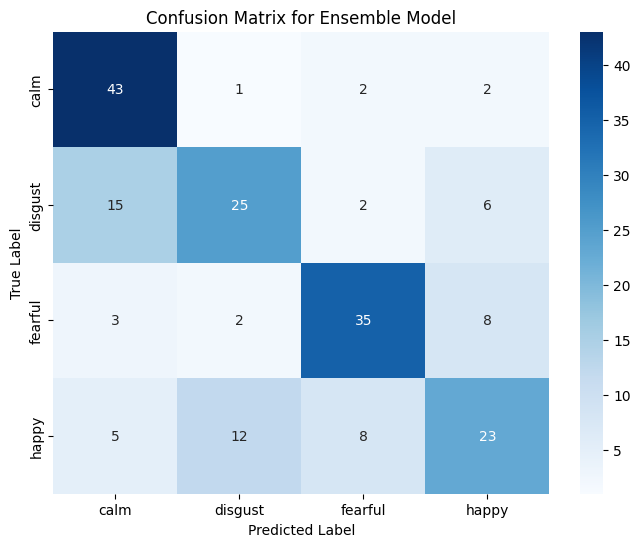

In [25]:
# Plot confusion matrix for the ensemble model
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_numeric, final_ensemble_y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=lb.classes_, yticklabels=lb.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Ensemble Model')
plt.show()